# **Importing Libraries**

In [13]:
# Standard Library Imports
import os            # OS-level operations (paths, directory handling)
import math          # Mathematical functions
import shutil        # High-level file operations (copying, moving, deleting)

# Data Handling & Processing
import numpy as np               # Numerical computations and array operations
import pandas as pd              # Data manipulation and analysis
import h5py                      # Handling HDF5 file formats

# Progress Visualization
from tqdm import tqdm            # Progress bars for loops

# Plotting & Visualization
import matplotlib.pyplot as plt  # Plotting and visualization tools


# PyTorch Machine Learning Stack
import torch                     # Core PyTorch library
import torch.nn as nn            # Neural network layers and utilities
import torch.optim as optim      # Optimization algorithms (SGD, Adam, etc.)
from torch.utils.data import (   # Dataset and DataLoader utilities
    DataLoader,
    Dataset
)
# Metrics
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# **Defining the architecture of sparse autoencoder**

In [14]:
"""
Sparse Autoencoder model.

Anthropic-style ReLU SAE with L1 sparsity penalty and unit-norm decoder
columns, following Bricken et al. (2023).
"""
import torch
import torch.nn as nn


class SparseAutoencoder(nn.Module):
    """ReLU sparse autoencoder for decomposing neural network activations.

    Args:
        d_input: Dimensionality of the input activations.
        d_hidden: Dictionary size (number of latent features).
    """

    def __init__(self, d_input: int, d_hidden: int):
        super().__init__()
        self.d_input = d_input
        self.d_hidden = d_hidden
        self.W_enc = nn.Linear(d_input, d_hidden, bias=True)
        self.W_dec = nn.Linear(d_hidden, d_input, bias=True)
        with torch.no_grad():
            self.W_dec.weight.data = nn.functional.normalize(
                self.W_dec.weight.data, dim=0
            )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Encode input activations into sparse feature activations."""
        return torch.relu(self.W_enc(x - self.W_dec.bias))

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode sparse features back to activation space."""
        return self.W_dec(z)

    def forward(self, x: torch.Tensor):
        """Full forward pass: encode then decode.

        Returns:
            x_hat: Reconstructed activations.
            z: Sparse feature activations.
        """
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

    def loss(self, x: torch.Tensor, lam: float):
        """Compute SAE loss = MSE + lambda * L1.

        Returns:
            total_loss, mse, l1, z
        """
        x_hat, z = self.forward(x)
        mse = (x - x_hat).pow(2).mean()
        l1 = z.abs().mean()
        return mse + lam * l1, mse, l1, z

    def normalize_decoder(self):
        """Constrain decoder column norms to unity (call after each step)."""
        with torch.no_grad():
            self.W_dec.weight.data = nn.functional.normalize(
                self.W_dec.weight.data, dim=0
            )

# **Defining custom dataset class for training on activations**

In [15]:
# Dataset class
class ActivationDataset(Dataset):
    def __init__(self, activation_path):
        self.x = torch.load(activation_path).float()
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx]

# **Function to get Sparse Features**

In [16]:
def get_sparse_features(activation_path, weight_path, latent_dim, device="cuda"):
    """
    A Function to get sparse features from sparse autoencoders

    parameters
    ----------
    activation_path: Path to activations dataset
    weight_path: Path to weights of trained SAE
    Latent dim: Dictionary size of the SAE

    Returns: Numpy array of sparse features
    """

    # Load the activation dataset
    x=torch.load(
        activation_path
    )

    # get the embedding dim
    input_dim=x.shape[1]
    # Load the trained sparse autoencoder
    model=SparseAutoencoder(
        input_dim,
        latent_dim
    )
    model.load_state_dict(
        torch.load(
            weight_path,
            map_location=device
        )["model"]
    )
    # Move the model to device
    model.to(device)
    # Set the model to eval mode
    model.eval()
    with torch.no_grad():
        # Get the sparse features for activation dataset
        z=model.encode(
            x.to(device)
        )
        print("Shape of the sparse autoencoder output")
        print(z.shape)
        # find out the number of total alive features
        active = z > 0
        alive_features = active.any(dim=0)
        num_alive = alive_features.sum().item()
        # print the alive features
        print("Alive features")
        print(num_alive)
        # Print the total dictionary size
        num_total = z.shape[1]
        print("Total dictionary size")
        print(num_total)
    return z.cpu()

# **Function to load the labels and Subject ids**

In [17]:
def load_analysis_data(label_path, subject_path):
    # loading the labels
    labels=torch.load(label_path).numpy()
    # loading the subject ids
    subjects=torch.load(subject_path).numpy()
    return labels,subjects

# **Function to do the task specific analysis**

In [18]:
def attention_specificity(features, labels, layer, top_k=20, save_path=None):
    """
    Analyze attention specificity of SAE features.
    Parameters
    ----------
    features : np.ndarray
        Sparse feature matrix
        Shape = (N_samples, N_features)

    labels : np.ndarray
        Binary labels
        0 = attended to left speaker
        1 = Attended to right speaker
    top_k : int
        Number of highest AUROC features to display.
    layer: string
        layer from which the activation is extracted
    save_path : str or None
        Folder to save figures. If None, figures are only shown.

    Returns
    -------
    results : dict
        scores
        raw_auc
        directions
        best_feature
        best_score
        top_features
    """

    print("ATTENTION SPECIFIC FEATURE ANALYSIS")

    # List to accumulate auc scores, raw auc scores and attended direction
    scores = []
    raw_scores = []
    directions = []
    # Initializing best feature and best score
    best_feature = None
    best_score = -1
    # Compute AUROC of every feature
    # loop over each feature
    for j in range(features.shape[1]):
        # get the feature j over all samples
        feature = features[:, j]
        # if standard deviation of feature j over all all rows is less than 1e-8,
        # then that feature is mostly zero
        if feature.std() < 1e-8:
            # so we discard that feature and give score of 0 to that feature
            scores.append(0.0)
            raw_scores.append(0.5)
            directions.append("Dead")
            # we skip remaining of the steps
            continue

        # get the auroc score for the feature
        raw_auc = roc_auc_score(labels, feature)
        # if the auc is greater than 0.5 then the feature is specific for right direction attention
        if raw_auc >= 0.5:
            direction = "Attended to right speaker"
            score = raw_auc
        # otherwise
        else:
            # the feature attends to left direction
            direction = "Attended to left speaker"
            score = 1 - raw_auc

        # Accumulate the scores and attended directions
        scores.append(score)
        raw_scores.append(raw_auc)
        directions.append(direction)
        # save the best score so far
        if score > best_score:
            best_score = score
            best_feature = j

    # get numpy array for scores and raw scores
    scores = np.array(scores)
    raw_scores = np.array(raw_scores)
    # Print summary
    print(f"\nBest Feature : {best_feature}")
    print(f"Best AUROC   : {best_score:.4f}")
    print(f"Detects      : {directions[best_feature]}")
    # Top features
    idx = np.argsort(scores)[::-1][:top_k]
    print(f"TOP {top_k} ATTENTION FEATURES")
    print(
        f"{'Rank':<6}"
        f"{'Feature':<10}"
        f"{'AUROC':<10}"
        f"{'Detects'}"
    )
    for rank, i in enumerate(idx, 1):
        print(
            f"{rank:<6}"
            f"{i:<10}"
            f"{scores[i]:<10.3f}"
            f"{directions[i]}"
        )

    
    # Scatter Plot
    plt.figure(figsize=(3.5, 2.6))
    # sort the scores
    sorted_idx = np.argsort(scores)[::-1]
    sorted_scores = scores[sorted_idx]
    # Defining the colors for each direction
    sorted_colors = []
    for i in sorted_idx:
        if directions[i] == "Attended to right speaker":
            sorted_colors.append("tab:blue")
        elif directions[i] == "Attended to left speaker":
            sorted_colors.append("tab:red")
        else:
            sorted_colors.append("gray")
    # line Plot
    plt.plot(sorted_scores, linewidth=2)
    # scatter plot
    plt.scatter(np.arange(len(sorted_scores)), sorted_scores, c=sorted_colors, s=18)
    plt.xlabel("Features (Ranked)")
    plt.ylabel("Best AUROC")
    plt.title(f"Ranked Attention Selectivity of SAE Features ({layer} layer)")
    plt.grid(alpha=0.3)
    # Saving the plot
    if save_path is not None:
        plt.savefig(
            f"{save_path}/attention_all_features_{layer}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()
    # Bargraph
    plt.figure(figsize=(3.5, 2.6))
    # define the colors
    bar_colors = []
    for i in idx:
        if directions[i] == "Attended to right speaker":
            bar_colors.append("tab:blue")
        elif directions[i] == "Attended to left speaker":
            bar_colors.append("tab:red")
        else:
            bar_colors.append("gray")
    # plotting the bar graph
    plt.bar(
        np.arange(top_k),
        scores[idx],
        color=bar_colors
    )
    plt.xticks(
        np.arange(top_k),
        idx,
        rotation=90
    )
    plt.ylabel("AUROC")
    plt.xlabel("Feature Index")
    plt.title(f"Top {top_k} Attention Features ({layer} layer)")
    # save the bar graph
    if save_path is not None:
        plt.savefig(
            f"{save_path}/attention_top_features_{layer}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()
    # Return everything
    return {
        "scores": scores,
        "raw_auc": raw_scores,
        "directions": directions,
        "best_feature": best_feature,
        "best_score": best_score,
        "top_features": idx
    }

## **Function to analyze the subject specificity**

In [19]:
def subject_specificity(features, subjects, layer, save_path = None):
    """
    Analyze subject specificity of SAE features.
    Parameters
    ----------
    features : np.ndarray
        Sparse feature matrix
        Shape = (N_samples, N_features)

    Subjects : np.ndarray
        Subject ids associated with each sample
    layer: string
        layer from which the activation is extracted
    save_path : str or None
        Folder to save figures. If None, figures are only shown.

    Returns
    -------
    results : numpy array
        Array stores the best auc for each subject
    """

    print("SUBJECT SPECIFIC FEATURE ANALYSIS")
    # Get the unique subjects
    unique=np.unique(subjects)
    # List to accumulate the results
    results=[]
    # loop over each unique subject id
    for sid in unique:
        # Develop a binary, which has 1 for the sample which has subject id sid
        y=(subjects==sid).astype(int)
        # initialize the best score for this subject id
        best=0
        # initialize the best feature for this subject id
        feat=0
        # For each feature
        for j in range(features.shape[1]):
            # if a feature is dead, then discard it and continue
            if features[:,j].std()<1e-8:
                continue
            # Get auroc score
            auc=roc_auc_score(y, features[:,j])
            auc=max(auc, 1-auc)
            # Get the best auroc and feature
            if auc>best:
                best=auc
                feat=j
        # display result
        print(f"Subject {sid:2d} | " f"Best Feature {feat:3d} | "f"AUROC {best:.3f}")
        # Accumulated the results
        results.append(best)

    # Plotting the bar graph
    plt.figure(figsize=(3.5, 2.6))
    plt.bar(unique,results)
    plt.xlabel("Subject")
    plt.ylabel("Best AUROC")
    plt.title(f"Subject Specificity ({layer} layer)")
    # save the bar graph
    if save_path is not None:
        plt.savefig(
            f"{save_path}/subject_specificity_{layer}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()
    return np.array(results)

# **Function to compare task versus subject specificity**

In [20]:
def task_vs_subject_analysis(features, labels, subjects, layer, save_path=None):
    """
    Compare attention selectivity and subject selectivity
    for every SAE feature.
    Parameters
    ----------
    features : ndarray
        (N, D)
    labels : ndarray
        Binary attention labels.
    subjects : ndarray
        Subject IDs.
    layer: string
        layer from which the activation is extracted
    save_path : str or None
        Folder to save figures. If None, figures are only shown.
    Returns
    -------
    results : dict
    """
    print("TASK vs SUBJECT FEATURE ANALYSIS")
    # get the unique subjects
    unique_subjects = np.unique(subjects)
    # Lists to accumulate task and subject score
    task_scores = []
    subject_scores = []
    # loop over each feature
    for j in range(features.shape[1]):
        # get the feature j
        feature = features[:, j]
        # if the feature is dead, then discard it
        if feature.std() < 1e-8:
            task_scores.append(0)
            subject_scores.append(0)
            continue
        # Get the attention auroc
        auc = roc_auc_score(labels, feature)
        task_auc = max(auc, 1 - auc)
        # initialize the best subject auroc
        best_subject_auc = 0
        # loop over each unique subject
        for sid in unique_subjects:
            # Develop a binary, which has 1 for the sample which has subject id sid
            y = (subjects == sid).astype(int)
            # get the subject auroc
            auc = roc_auc_score(y, feature)
            auc = max(auc, 1 - auc)
            # saving the best subject auc
            if auc > best_subject_auc:
                best_subject_auc = auc
        # accumulating the task and subject scores
        task_scores.append(task_auc)
        subject_scores.append(best_subject_auc)
    # get numpy array of task and subject score list
    task_scores = np.array(task_scores)
    subject_scores = np.array(subject_scores) 
    # Scatter plot
    plt.figure(figsize=(3.5, 2.6))
    plt.scatter(
        subject_scores,
        task_scores,
        alpha=0.7,
        s=25
    )
    plt.axhline(
        0.5,
        color="black",
        linestyle="--"
    )
    plt.axvline(
        0.5,
        color="black",
        linestyle="--"
    )
    plt.xlabel("Best Subject AUROC")
    plt.ylabel("Attention AUROC")
    plt.title(f"Task vs Subject Selectivity of SAE Features ({layer} layer)")
    plt.grid(alpha=0.3)
    # saving the figure
    if save_path is not None:
        plt.savefig(
            f"{save_path}/task_vs_subject_{layer}.png",
            dpi=300,
            bbox_inches="tight"
        )
    plt.show()

    # Print summary
    task_dominant = np.sum(task_scores > subject_scores)
    subject_dominant = np.sum(subject_scores > task_scores)
    equal = np.sum(np.isclose(task_scores, subject_scores))
    print(f"Task-dominant Features    : {task_dominant}")
    print(f"Subject-dominant Features : {subject_dominant}")
    print(f"Equal                     : {equal}")

    # Top task features
    idx = np.argsort(task_scores)[::-1][:10]
    print("Top Task-selective Features")
    print(
        f"{'Feature':<10}"
        f"{'Task':<10}"
        f"{'Subject'}"
    )
    for i in idx:
        print(
            f"{i:<10}"
            f"{task_scores[i]:<10.3f}"
            f"{subject_scores[i]:.3f}"
        )
    # Top subject features
    idx = np.argsort(subject_scores)[::-1][:10]
    print("Top Subject-selective Features")
    print(
        f"{'Feature':<10}"
        f"{'Subject':<10}"
        f"{'Task'}"
    )
    for i in idx:
        print(
            f"{i:<10}"
            f"{subject_scores[i]:<10.3f}"
            f"{task_scores[i]:.3f}"
        )
    # return the task and subject scores
    return {
        "task_scores": task_scores,
        "subject_scores": subject_scores
    }

# **Getting the sparse autoencoder encoding for temporal, spatial and lstm layer**

In [21]:
z_temporal = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/val/temporal.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_temporal/best_sae.pt",
    latent_dim = 512
)

z_spatial = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/val/spatial.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_spatial/best_sae.pt",
    latent_dim = 512
)

z_lstm = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/val/lstm.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_lstm/best_sae.pt",
    latent_dim = 1024
)

z_pooled = get_sparse_features(
    activation_path="/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/val/pooled.pt",
    weight_path="/kaggle/input/notebooks/sumanpunshi123/sae-training/sae_pooled/best_sae.pt",
    latent_dim = 1024
)


Shape of the sparse autoencoder output
torch.Size([26320, 512])
Alive features
142
Total dictionary size
512
Shape of the sparse autoencoder output
torch.Size([26320, 512])
Alive features
409
Total dictionary size
512
Shape of the sparse autoencoder output
torch.Size([26320, 1024])
Alive features
338
Total dictionary size
1024
Shape of the sparse autoencoder output
torch.Size([26320, 1024])
Alive features
342
Total dictionary size
1024


# **Attention specificity analysis**

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 6
Best AUROC   : 0.5160
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     6         0.516     Attended to right speaker
2     366       0.515     Attended to right speaker
3     277       0.513     Attended to left speaker
4     168       0.512     Attended to left speaker
5     158       0.510     Attended to left speaker
6     247       0.510     Attended to left speaker
7     124       0.504     Attended to left speaker
8     319       0.501     Attended to left speaker
9     299       0.501     Attended to right speaker
10    490       0.501     Attended to left speaker
11    390       0.501     Attended to left speaker
12    176       0.501     Attended to left speaker
13    238       0.501     Attended to left speaker
14    413       0.501     Attended to left speaker
15    31        0.501     Attended to left speaker
16    159       0.501     Attended to left speaker
17  

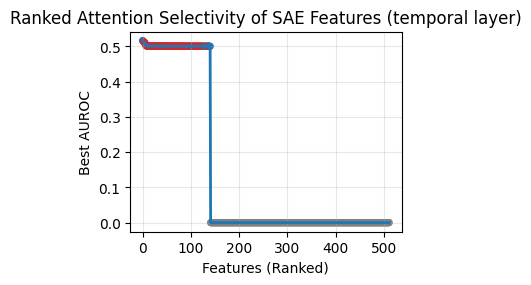

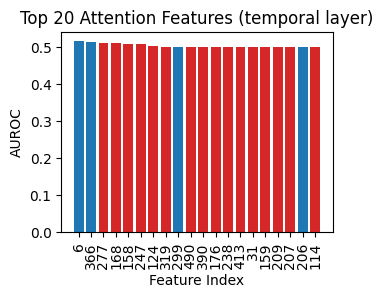

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 382
Best AUROC   : 0.5605
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     382       0.560     Attended to right speaker
2     188       0.558     Attended to right speaker
3     69        0.549     Attended to left speaker
4     362       0.549     Attended to left speaker
5     41        0.540     Attended to left speaker
6     381       0.538     Attended to right speaker
7     459       0.537     Attended to left speaker
8     446       0.532     Attended to right speaker
9     150       0.531     Attended to right speaker
10    144       0.530     Attended to left speaker
11    444       0.526     Attended to left speaker
12    14        0.524     Attended to left speaker
13    433       0.524     Attended to left speaker
14    476       0.522     Attended to right speaker
15    398       0.522     Attended to right speaker
16    424       0.521     Attended to left speake

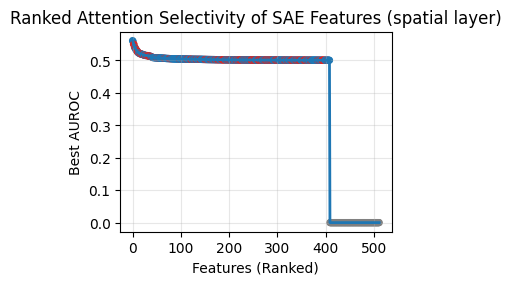

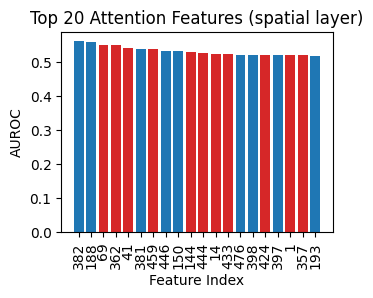

ATTENTION SPECIFIC FEATURE ANALYSIS

Best Feature : 726
Best AUROC   : 0.5603
Detects      : Attended to right speaker
TOP 20 ATTENTION FEATURES
Rank  Feature   AUROC     Detects
1     726       0.560     Attended to right speaker
2     445       0.559     Attended to right speaker
3     362       0.546     Attended to right speaker
4     67        0.537     Attended to right speaker
5     210       0.537     Attended to left speaker
6     282       0.534     Attended to right speaker
7     797       0.533     Attended to right speaker
8     330       0.533     Attended to left speaker
9     187       0.533     Attended to right speaker
10    936       0.532     Attended to right speaker
11    398       0.532     Attended to right speaker
12    190       0.532     Attended to right speaker
13    272       0.532     Attended to right speaker
14    422       0.531     Attended to right speaker
15    702       0.531     Attended to right speaker
16    968       0.530     Attended to left 

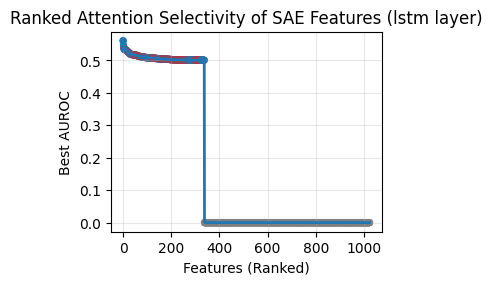

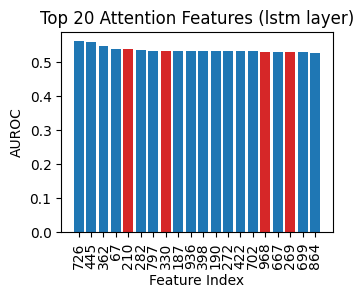

In [22]:
labels, subjects = load_analysis_data("/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/val/labels.pt",
                                     "/kaggle/input/notebooks/sumanpunshi123/extract-activations/activations/val/subjects.pt")

result_dict_temporal = attention_specificity(z_temporal, labels, "temporal", save_path = "/kaggle/working/")
result_dict_spatial = attention_specificity(z_spatial, labels, "spatial", save_path = "/kaggle/working/")
result_dict_lstm = attention_specificity(z_lstm, labels, "lstm", save_path = "/kaggle/working/")

# **Subject Specificity analysis**

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 451 | AUROC 0.727
Subject  1 | Best Feature 277 | AUROC 0.762
Subject  2 | Best Feature 299 | AUROC 0.590
Subject  5 | Best Feature 277 | AUROC 0.586


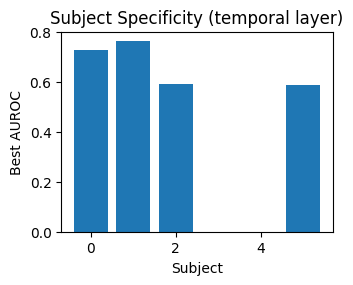

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature 315 | AUROC 0.628
Subject  1 | Best Feature  56 | AUROC 0.600
Subject  2 | Best Feature   1 | AUROC 0.616
Subject  5 | Best Feature   1 | AUROC 0.656


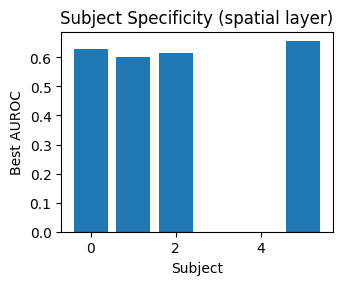

SUBJECT SPECIFIC FEATURE ANALYSIS
Subject  0 | Best Feature  67 | AUROC 0.687
Subject  1 | Best Feature 691 | AUROC 0.578
Subject  2 | Best Feature 423 | AUROC 0.573
Subject  5 | Best Feature  10 | AUROC 0.629


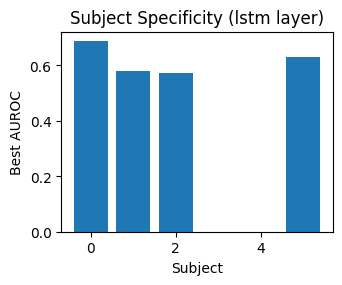

In [23]:
result_temporal = subject_specificity(z_temporal, subjects, "temporal", save_path = "/kaggle/working/")
result_spatial = subject_specificity(z_spatial, subjects, "spatial", save_path = "/kaggle/working/")
result_lstm = subject_specificity(z_lstm, subjects, "lstm", save_path = "/kaggle/working/")

# **Task vs Subject Specificity analysis**

TASK vs SUBJECT FEATURE ANALYSIS


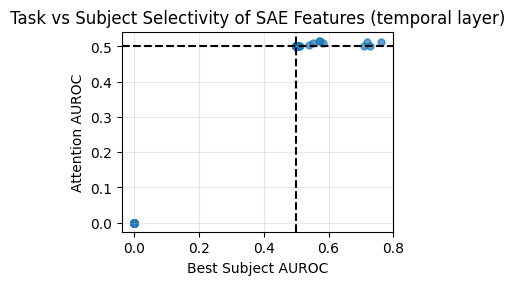

Task-dominant Features    : 7
Subject-dominant Features : 134
Equal                     : 372
Top Task-selective Features
Feature   Task      Subject
6         0.516     0.574
366       0.515     0.571
277       0.513     0.762
168       0.512     0.718
158       0.510     0.582
247       0.510     0.551
124       0.504     0.539
319       0.501     0.503
299       0.501     0.711
490       0.501     0.502
Top Subject-selective Features
Feature   Subject   Task
277       0.762     0.513
451       0.727     0.500
168       0.718     0.512
299       0.711     0.501
158       0.582     0.510
6         0.574     0.516
366       0.571     0.515
247       0.551     0.510
124       0.539     0.504
420       0.511     0.500
TASK vs SUBJECT FEATURE ANALYSIS


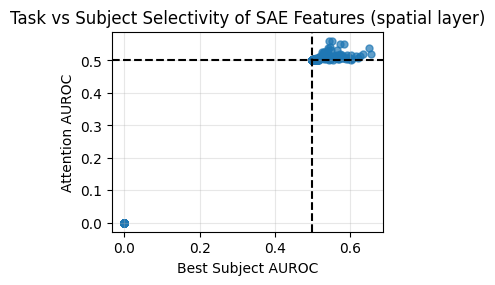

Task-dominant Features    : 7
Subject-dominant Features : 402
Equal                     : 103
Top Task-selective Features
Feature   Task      Subject
382       0.560     0.553
188       0.558     0.543
69        0.549     0.575
362       0.549     0.585
41        0.540     0.548
381       0.538     0.541
459       0.537     0.651
446       0.532     0.543
150       0.531     0.549
144       0.530     0.566
Top Subject-selective Features
Feature   Subject   Task
1         0.656     0.519
459       0.651     0.537
284       0.634     0.518
315       0.628     0.513
470       0.620     0.506
452       0.617     0.514
54        0.605     0.503
175       0.603     0.502
229       0.603     0.517
463       0.601     0.503
TASK vs SUBJECT FEATURE ANALYSIS


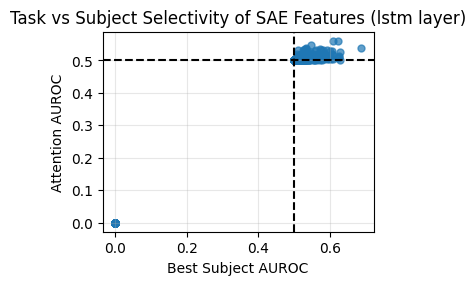

Task-dominant Features    : 14
Subject-dominant Features : 324
Equal                     : 686
Top Task-selective Features
Feature   Task      Subject
726       0.560     0.622
445       0.559     0.608
362       0.546     0.546
67        0.537     0.687
210       0.537     0.534
282       0.534     0.532
797       0.533     0.572
330       0.533     0.530
187       0.533     0.511
936       0.532     0.579
Top Subject-selective Features
Feature   Subject   Task
67        0.687     0.537
72        0.629     0.524
10        0.629     0.501
328       0.625     0.514
459       0.624     0.508
419       0.623     0.507
726       0.622     0.560
436       0.609     0.504
445       0.608     0.559
256       0.608     0.515


In [24]:
score_temporal = task_vs_subject_analysis(z_temporal, labels, subjects, "temporal", save_path = "/kaggle/working/")
score_spatial = task_vs_subject_analysis(z_spatial, labels, subjects, "spatial", save_path = "/kaggle/working/")
score_lstm = task_vs_subject_analysis(z_lstm, labels, subjects, "lstm", save_path = "/kaggle/working/")